# Evaluación de embeddings v2 (TrajectoryAutoencoder)

Evalúa el embedding comprimido `z` que produce `land2vec.model.TrajectoryAutoencoder`
sobre las mismas 7 zonas out-of-domain de `notebooks/eval_ood_zones.ipynb`, en
cuatro frentes (ver el plan de la v2):

1. **Fidelidad de reconstrucción** por zona y curva de compresión vs. `d`.
2. **Clustering / tipología** de trayectorias sobre `z`.
3. **Probing**: `z` como insumo para predecir clase dominante / transición /
   ecorregión, comparado contra la secuencia cruda one-hot y el estado oculto
   de la v1 (`GPTDecoder.hidden_states()`) promediado.
4. **Visualización** de `z` en 2D (PCA/UMAP).

**Prerrequisito**: este notebook asume que ya corriste el barrido
(`scripts/train_autoencoder.py --sweep dim` y `--sweep secondary`, en Colab con
GPU -- ver el plan) y que existen `models/sweep_dim/d*/`, `models/sweep_secondary/*/`
y el modelo final elegido en `models/autoencoder_v2/`. Si esas carpetas no
existen todavía, las celdas que las usan van a fallar -- correr primero el
barrido.

In [1]:
import dataclasses
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from land2vec.dataset import SequenceDatasetAutoencoder
from land2vec.tokenizer import Tokenizer
from land2vec.utils import load_config, load_model, compute_metrics

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ZONES = [
    "puna_noa",
    "patagonia_estepa",
    "periurbano_cordoba",
    "ibera",
    "delta_parana",
    "pampa_nucleo",
    "misiones_selva",
]
VALID_LABELS = [i for i in Tokenizer.VOCAB.values() if i != Tokenizer.VOCAB["[UNK]"]]
LABEL_NAMES = [Tokenizer.REVERSE_VOCAB[i] for i in VALID_LABELS]

In [2]:
def load_zone_seqs(zone: str) -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / f"id_seqs_text_2000_2022_{zone}.zip")


def load_zone_coords(zone: str) -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / f"lat_long_df_{zone}.zip", usecols=["ID", "latitude", "longitude"])


@torch.inference_mode()
def encode_zone(model, seqs: pd.Series, batch_size: int = 1024) -> np.ndarray:
    "z (N, embed_dim) para todas las secuencias de una zona, en su orden original."
    loader = DataLoader(SequenceDatasetAutoencoder(seqs), shuffle=False, batch_size=batch_size)
    model.eval()
    chunks = [model.encode(x.to(DEVICE)).cpu() for x, _ in loader]
    return torch.cat(chunks).numpy()


@torch.inference_mode()
def reconstruction_metrics(model, seqs: pd.Series, batch_size: int = 1024) -> dict:
    "Accuracy/macro-F1 de reconstrucción (los 23 estados) sobre una zona completa."
    loader = DataLoader(SequenceDatasetAutoencoder(seqs), shuffle=False, batch_size=batch_size)
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        logits = model(x.to(DEVICE))
        all_preds.append(logits.argmax(-1).cpu().reshape(-1))
        all_targets.append(y.reshape(-1))
    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    metrics = compute_metrics(targets, preds, labels=VALID_LABELS)
    metrics["confusion_matrix"] = confusion_matrix(targets, preds, labels=VALID_LABELS, normalize="true")
    return metrics

def had_transition(seq: str) -> bool:
    "True si la secuencia tiene al menos un cambio de estado en los 23 años."
    return len(set(seq.split("-"))) > 1


## 1. Fidelidad de reconstrucción

### 1a. Curva de compresión: reconstrucción out-of-domain vs. `d`

Carga cada modelo del barrido primario (`models/sweep_dim/d*/`) y mide
accuracy/macro-F1 de reconstrucción sobre las 7 zonas out-of-domain (pooled) --
a diferencia del `val_macro_f1` que reporta el barrido (que es in-domain,
sobre el propio split de entrenamiento), esta curva usa el mismo benchmark
held-out que la v1.

100%|██████████| 3344976/3344976 [00:37<00:00, 88497.39it/s] 


d= 12 accuracy=0.9998 macro_f1=0.8994


100%|██████████| 3344976/3344976 [00:37<00:00, 89969.10it/s] 


d= 16 accuracy=0.9995 macro_f1=0.8984


100%|██████████| 3344976/3344976 [00:36<00:00, 91403.27it/s] 


d= 32 accuracy=0.9998 macro_f1=0.8995


100%|██████████| 3344976/3344976 [00:39<00:00, 84567.92it/s] 


d=  4 accuracy=0.9991 macro_f1=0.8977


100%|██████████| 3344976/3344976 [00:42<00:00, 77878.34it/s] 


d=  8 accuracy=0.9997 macro_f1=0.8989


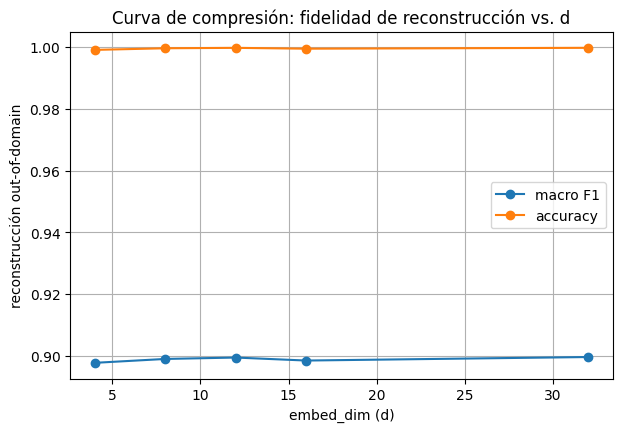

In [3]:
zone_seqs = {zone: load_zone_seqs(zone)["seqs"] for zone in ZONES}
pooled_seqs = pd.concat(zone_seqs.values(), ignore_index=True)

sweep_dim_dir = MODELS_DIR / "sweep_dim"
dim_curve = []
for run_dir in sorted(sweep_dim_dir.glob("d*")):
    config = dataclasses.replace(load_config(run_dir), device=DEVICE)
    model = load_model(config, run_dir).to(DEVICE)
    metrics = reconstruction_metrics(model, pooled_seqs)
    dim_curve.append({"d": config.embed_dim, "accuracy": metrics["accuracy"], "macro_f1": metrics["macro_f1"]})
    print(f"d={config.embed_dim:>3d} accuracy={metrics['accuracy']:.4f} macro_f1={metrics['macro_f1']:.4f}")

dim_curve = pd.DataFrame(dim_curve).sort_values("d")
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dim_curve["d"], dim_curve["macro_f1"], marker="o", label="macro F1")
ax.plot(dim_curve["d"], dim_curve["accuracy"], marker="o", label="accuracy")
ax.set_xlabel("embed_dim (d)")
ax.set_ylabel("reconstrucción out-of-domain")
ax.set_title("Curva de compresión: fidelidad de reconstrucción vs. d")
ax.legend()
ax.grid(True)
plt.show()

### 1b. Barrido secundario (lr, n_layer, pooling, pesos de clase) al `d` elegido

In [4]:
sweep_secondary_dir = MODELS_DIR / "sweep_secondary"
secondary_results = []
for run_dir in sorted(sweep_secondary_dir.iterdir()):
    if not run_dir.is_dir():
        continue
    config = dataclasses.replace(load_config(run_dir), device=DEVICE)
    model = load_model(config, run_dir).to(DEVICE)
    metrics = reconstruction_metrics(model, pooled_seqs)
    secondary_results.append({
        "run": run_dir.name, "lr": config.lr, "n_layer": config.n_layer, "pooling": config.pooling,
        "accuracy": metrics["accuracy"], "macro_f1": metrics["macro_f1"],
    })

pd.DataFrame(secondary_results).sort_values("macro_f1", ascending=False)

100%|██████████| 3344976/3344976 [00:36<00:00, 91361.95it/s] 


,run,lr,n_layer,pooling,accuracy,macro_f1
5,n_layer_2_query,0.0010,2,query,0.999864,0.899622
1,lr_bajo,0.0003,4,mean,0.999792,0.899478
2,lr_bajo_n_layer_2,0.0003,2,mean,0.999782,0.899374
0,baseline,0.0010,4,mean,0.999761,0.899317
3,lr_bajo_query,0.0003,4,query,0.999709,0.899264
4,n_layer_2,0.0010,2,mean,0.999742,0.899236
7,sin_pesos,0.0010,4,mean,0.999715,0.899048
6,pooling_query,0.0010,4,query,0.999618,0.898859


### 1c. Modelo final: reconstrucción por zona + matrices de confusión

embed_dim=8 n_layer=2 pooling=query


100%|██████████| 388800/388800 [00:04<00:00, 89414.20it/s]


[puna_noa] accuracy=0.9996 macro_f1=0.8985


100%|██████████| 1555200/1555200 [00:17<00:00, 90743.89it/s] 


[patagonia_estepa] accuracy=0.9999 macro_f1=0.8577


...

[delta_parana] accuracy=0.9998 macro_f1=0.8926


100%|██████████| 518400/518400 [00:05<00:00, 88850.69it/s] 


[pampa_nucleo] accuracy=0.9999 macro_f1=0.8976


100%|██████████| 388800/388800 [00:04<00:00, 84555.31it/s]


[misiones_selva] accuracy=0.9999 macro_f1=0.6992


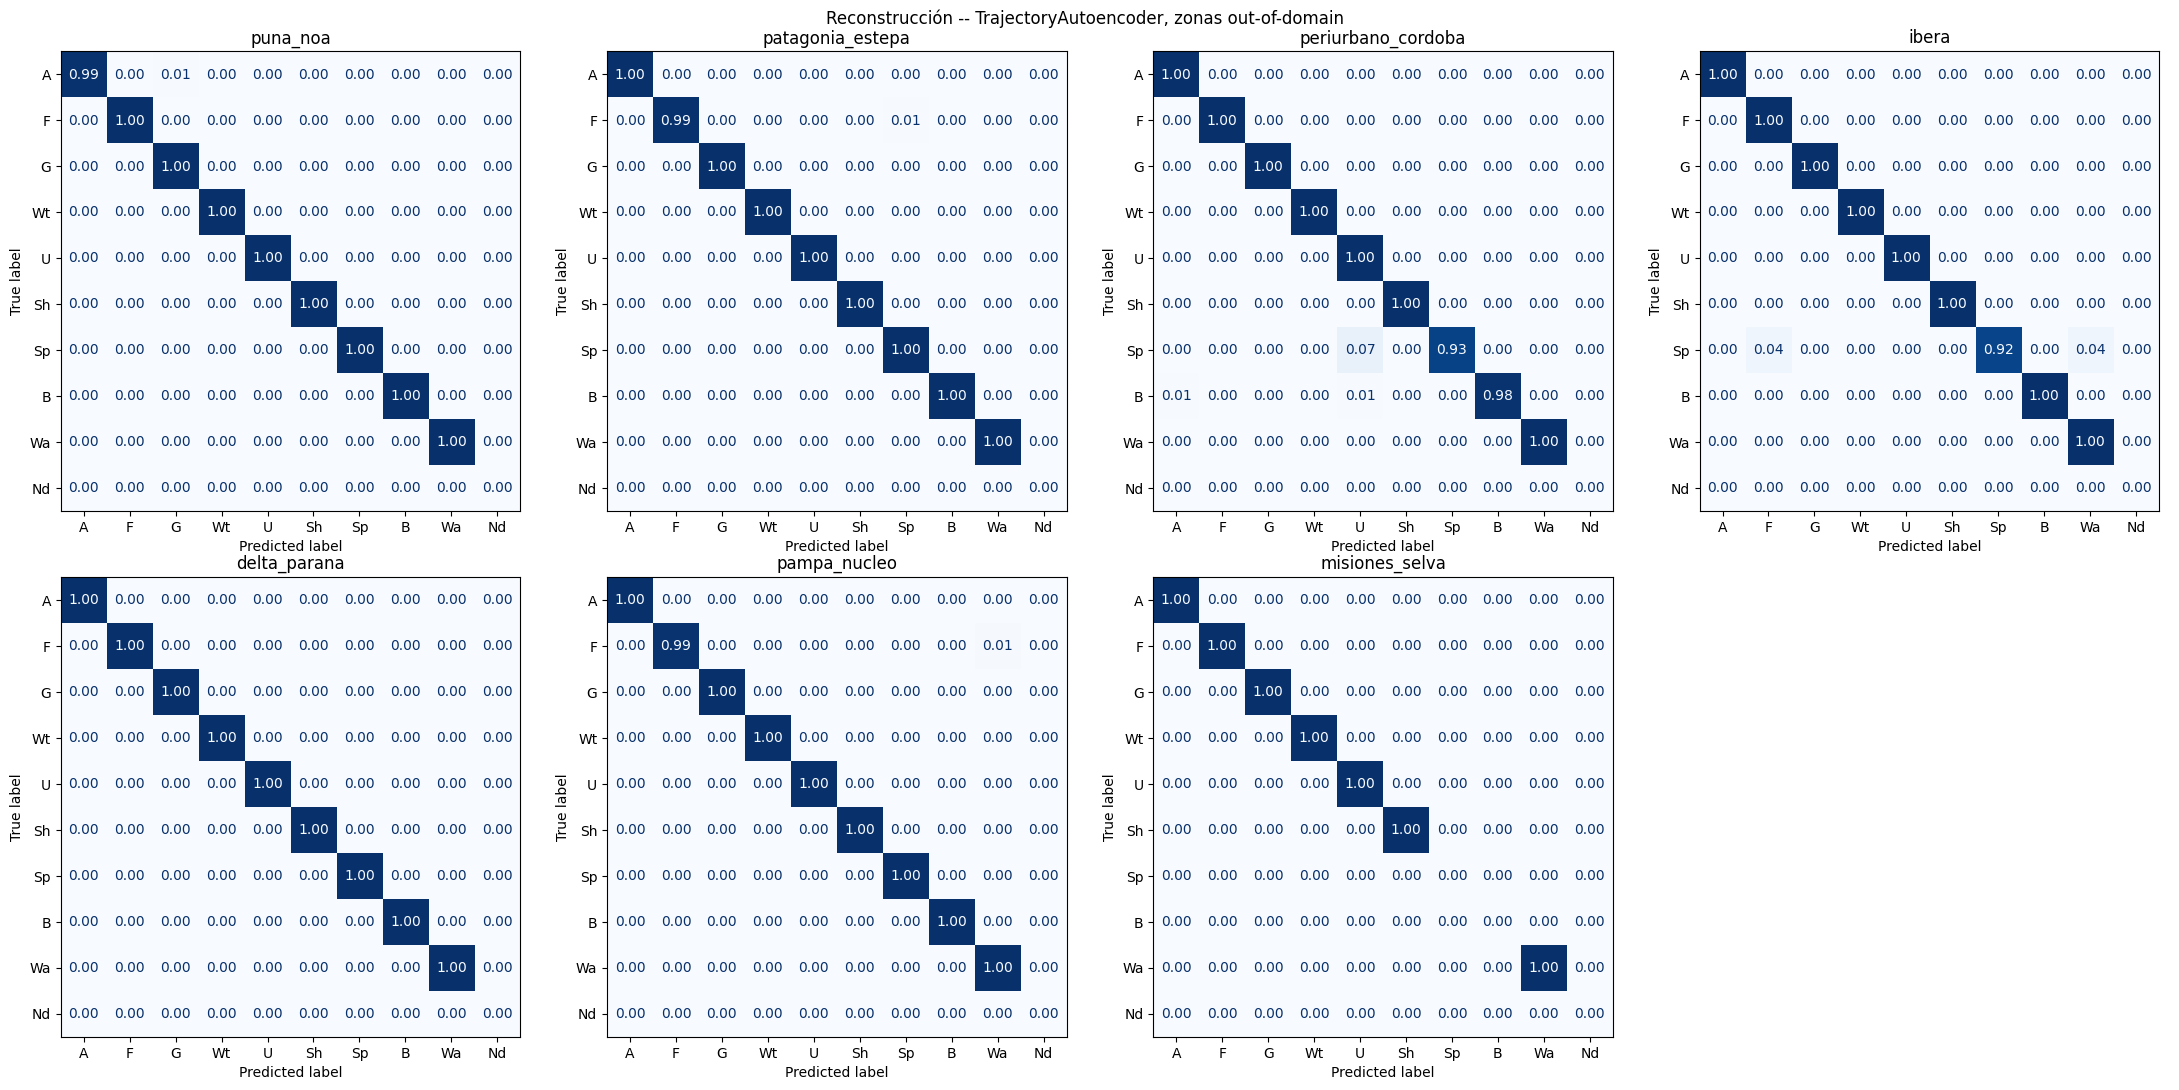

In [5]:
final_config = dataclasses.replace(load_config(MODELS_DIR / "autoencoder_v2"), device=DEVICE)
final_model = load_model(final_config, MODELS_DIR / "autoencoder_v2").to(DEVICE)
print(f"embed_dim={final_config.embed_dim} n_layer={final_config.n_layer} pooling={final_config.pooling}")

zone_results = {}
for zone in ZONES:
    m = reconstruction_metrics(final_model, zone_seqs[zone])
    zone_results[zone] = m
    print(f"[{zone}] accuracy={m['accuracy']:.4f} macro_f1={m['macro_f1']:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
for ax, zone in zip(axes.flat, ZONES):
    disp = ConfusionMatrixDisplay(confusion_matrix=zone_results[zone]["confusion_matrix"], display_labels=LABEL_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(zone)
    ax.grid(False)
axes.flat[-1].axis("off")
fig.suptitle("Reconstrucción -- TrajectoryAutoencoder, zonas out-of-domain")
fig.tight_layout()
plt.show()

In [6]:
# Desglose: ¿la reconstrucción es mucho peor específicamente en las secuencias
# con transición? El promedio pooled por zona (celda anterior) puede estar
# dominado por las secuencias constantes (triviales de reconstruir), que son
# mayoría en las zonas de eval (a diferencia del train, submuestreado al 15%).
constant_vs_dynamic = []
for zone in ZONES:
    seqs = zone_seqs[zone]
    mask = seqs.apply(had_transition).values
    for label, subset in [("constante", seqs[~mask]), ("con transición", seqs[mask])]:
        if len(subset) == 0:
            continue
        m = reconstruction_metrics(final_model, subset)
        constant_vs_dynamic.append({
            "zona": zone, "tipo": label, "n": len(subset),
            "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
        })

df_const_dyn = pd.DataFrame(constant_vs_dynamic)
df_const_dyn.pivot(index="zona", columns="tipo", values=["n", "accuracy", "macro_f1"])


100%|██████████| 15233/15233 [00:00<00:00, 80691.17it/s]


n                  accuracy            \
tipo               con transición  constante con transición constante   
zona                                                                    
delta_parana              11347.0   170093.0       0.996387       1.0   
ibera                     30702.0   260898.0       0.997918       1.0   
misiones_selva            15233.0   373567.0       0.997151       1.0   
pampa_nucleo               7374.0   511026.0       0.989870       1.0   
patagonia_estepa          10770.0  1544430.0       0.986420       1.0   
periurbano_cordoba         2106.0    18630.0       0.994736       1.0   
puna_noa                  29830.0   358970.0       0.995362       1.0   

                         macro_f1            
tipo               con transición constante  
zona                                         
delta_parana             0.773347       0.9  
ibera                    0.794544       0.9  
misiones_selva           0.694544       0.7  
pampa_nucleo             0.887186       0.8  
patagonia_estepa         0.780886       0.9  
periurbano_cordoba       0.887845       0.7  
puna_noa                 0.880432       0.9

## 2. Clustering / tipología de trayectorias

k-means sobre `z` (pooled, las 7 zonas), silhouette score, coherencia espacial
(mapeando los clusters a lat/long) y decodificación de los centroides a
trayectorias prototípicas legibles.

In [7]:
pooled_z = np.concatenate([encode_zone(final_model, zone_seqs[zone]) for zone in ZONES])
zone_labels = np.concatenate([[zone] * len(zone_seqs[zone]) for zone in ZONES])

# Clusterizar solo sobre secuencias CON transición: las constantes son mayoría en
# las zonas de eval (nunca submuestreadas, a diferencia del train) y con k chico
# ahogan cualquier tipología real -- el clustering degenera en "una clase, un
# cluster" (ver docs/v2_autoencoder_training.md / discusión de esta corrida).
dynamic_mask = pooled_seqs.apply(had_transition).values
pooled_z_dyn = pooled_z[dynamic_mask]
zone_labels_dyn = zone_labels[dynamic_mask]
print(f"secuencias con transición: {dynamic_mask.sum():,} / {len(dynamic_mask):,} ({dynamic_mask.mean()*100:.1f}%)")

k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(pooled_z_dyn)
sil = silhouette_score(pooled_z_dyn, kmeans.labels_, sample_size=20000, random_state=42)
print(f"k={k} silhouette={sil:.4f}")

# Coherencia espacial: composición de zonas por cluster
composition = pd.crosstab(kmeans.labels_, zone_labels_dyn, normalize="index").round(2)
composition

100%|██████████| 388800/388800 [00:04<00:00, 92301.95it/s] 


secuencias con transición: 107,362 / 3,344,976 (3.2%)
k=8 silhouette=0.4114


col_0,delta_parana,ibera,misiones_selva,pampa_nucleo,patagonia_estepa,periurbano_cordoba,puna_noa
row_0,,,,,,,
0,0.16,0.73,0.00,0.10,0.00,0.00,0.00
1,0.20,0.28,0.11,0.08,0.01,0.05,0.26
2,0.04,0.12,0.52,0.05,0.13,0.01,0.13
3,0.22,0.17,0.37,0.15,0.00,0.06,0.03
4,0.01,0.36,0.15,0.04,0.36,0.04,0.02
5,0.00,0.00,0.00,0.00,0.05,0.00,0.95
6,0.12,0.04,0.04,0.02,0.16,0.00,0.61
7,0.01,0.10,0.07,0.03,0.35,0.00,0.43


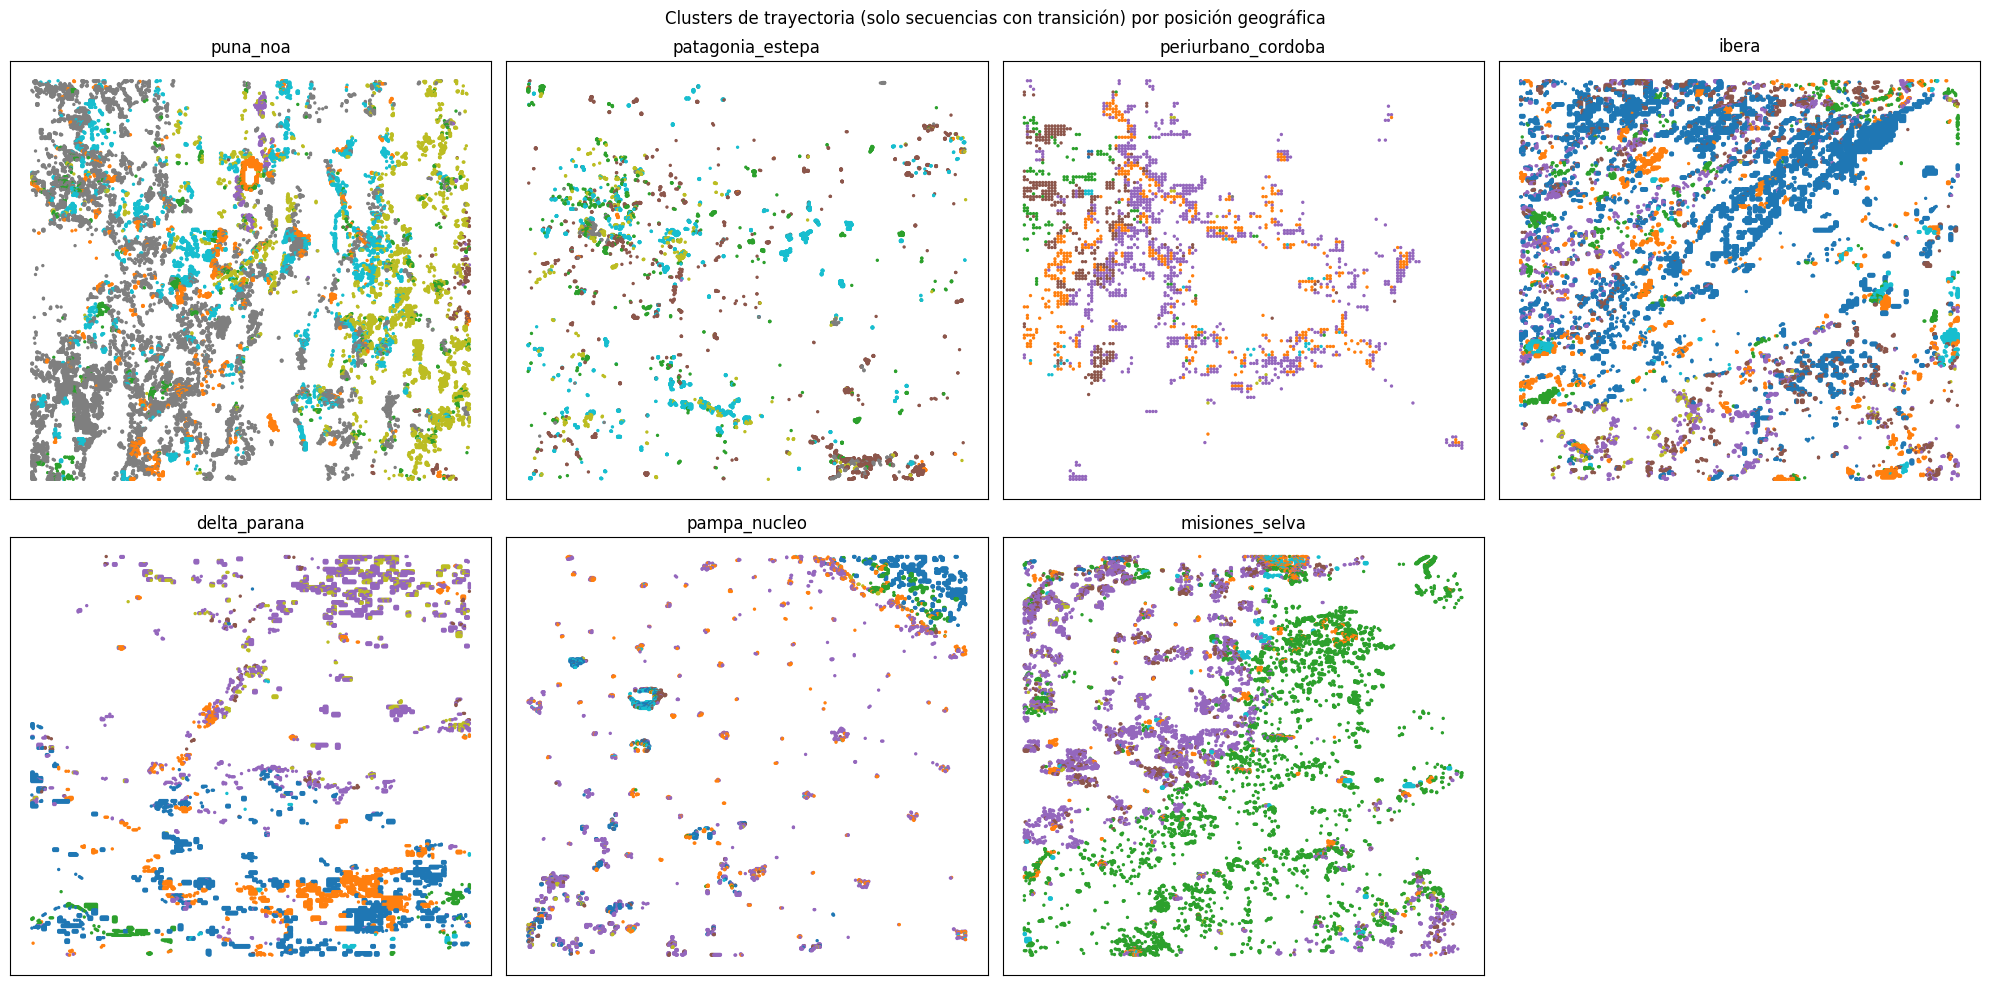

In [8]:
# Mapa: color = cluster, un panel por zona (usa las coordenadas ya construidas)
# Mismo filtro que la celda anterior: solo píxeles con transición.
coords = pd.concat([load_zone_coords(zone).assign(zone=zone) for zone in ZONES], ignore_index=True)
coords_dyn = coords[dynamic_mask].copy()
coords_dyn["cluster"] = kmeans.labels_

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, zone in zip(axes.flat, ZONES):
    sub = coords_dyn[coords_dyn["zone"] == zone]
    sc = ax.scatter(sub["longitude"], sub["latitude"], c=sub["cluster"], cmap="tab10", s=2, vmin=0, vmax=k - 1)
    ax.set_title(zone)
    ax.set_xticks([]); ax.set_yticks([])
axes.flat[-1].axis("off")
fig.suptitle("Clusters de trayectoria (solo secuencias con transición) por posición geográfica")
fig.tight_layout()
plt.show()

In [9]:
# Trayectoria prototípica de cada cluster: decodificar el centroide en espacio z
with torch.inference_mode():
    centroids = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32, device=DEVICE)
    proto_logits = final_model.decode(centroids)
    proto_tokens = proto_logits.argmax(-1).cpu()

for i in range(k):
    seq = Tokenizer.decode(proto_tokens[i])
    print(f"cluster {i} (n={sum(kmeans.labels_ == i):>6,}): {seq}")

cluster 0 (n=25,966): F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt
cluster 1 (n=10,559): Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-A-A-F-F-F-F-F-F-F-F-F-F-F-F
cluster 2 (n=10,732): F-F-F-F-F-F-F-F-F-F-F-F-F-F-F-F-F-B-B-Sh-Sh-Sh-Sh
cluster 3 (n=15,951): F-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-F-A
cluster 4 (n= 8,803): F-F-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-F
cluster 5 (n=16,183): B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp
cluster 6 (n= 7,618): F-F-G-G-G-G-G-G-G-G-G-G-G-G-G-G-G-Sp-Sp-Sp-G-G-Sp
cluster 7 (n=11,550): B-B-B-B-B-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp


## 3. Probing: `z` como insumo para otro modelo

Compara tres representaciones como entrada a una regresión logística simple,
sobre tres tareas: clase dominante de la trayectoria, si hubo alguna
transición, y ecorregión (zona) de origen:

- `z` (el embedding de la v2, `embed_dim` dims).
- Secuencia cruda one-hot (23 × 11 = 253 dims) -- el "sin comprimir".
- Estado oculto de la v1 promediado sobre posiciones (128 dims,
  `GPTDecoder.hidden_states(x).mean(dim=1)`) -- ¿aporta el autoencoder algo
  sobre simplemente poolear el modelo que ya existe?

In [ ]:
v1_config = dataclasses.replace(load_config(MODELS_DIR / "full_model"), device=DEVICE)
v1_model = load_model(v1_config, MODELS_DIR / "full_model").to(DEVICE)


@torch.inference_mode()
def v1_pooled_hidden(seqs: pd.Series, batch_size: int = 1024) -> np.ndarray:
    "Estado oculto de la v1 (128 dims), promediado sobre las 22 posiciones de contexto."
    loader = DataLoader(SequenceDatasetAutoencoder(seqs), shuffle=False, batch_size=batch_size)
    v1_model.eval()
    chunks = []
    for x, _ in loader:
        h = v1_model.hidden_states(x[:, :-1].to(DEVICE))  # mismo largo de contexto que en entrenamiento (block_size=22)
        chunks.append(h.mean(dim=1).cpu())
    return torch.cat(chunks).numpy()


def one_hot_flat(seqs: pd.Series) -> np.ndarray:
    "Secuencia cruda, one-hot por posición y aplanada (23*11 dims)."
    encoded = np.stack([Tokenizer.encode(s) for s in seqs])
    return np.eye(len(Tokenizer.VOCAB))[encoded].reshape(len(seqs), -1)


pooled_onehot = one_hot_flat(pooled_seqs)
pooled_v1_hidden = np.concatenate([v1_pooled_hidden(zone_seqs[zone]) for zone in ZONES])
print("z:", pooled_z.shape, "one-hot:", pooled_onehot.shape, "v1 hidden:", pooled_v1_hidden.shape)

100%|██████████| 388800/388800 [00:04<00:00, 92377.26it/s] 


In [1]:
def dominant_class(seq: str) -> str:
    return pd.Series(seq.split("-")).mode().iloc[0]


labels_dominant = pooled_seqs.apply(dominant_class).values
labels_transition = pooled_seqs.apply(had_transition).values
labels_zone = zone_labels

representations = {"z (v2)": pooled_z, "one-hot crudo": pooled_onehot, "v1 hidden pooled": pooled_v1_hidden}
tasks = {"clase dominante": labels_dominant, "hubo transición": labels_transition, "ecorregión": labels_zone}

probe_results = []
for task_name, y in tasks.items():
    for repr_name, X in representations.items():
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        acc = clf.score(X_test, y_test)
        probe_results.append({"tarea": task_name, "representación": repr_name, "accuracy": acc})
        print(f"{task_name:18s} | {repr_name:18s} | accuracy={acc:.4f}")

pd.DataFrame(probe_results).pivot(index="tarea", columns="representación", values="accuracy")

NameError: name 'pooled_seqs' is not defined

## 4. Visualización: PCA de `z` a 2D

In [ ]:
pca = PCA(n_components=2, random_state=42)
z_2d = pca.fit_transform(pooled_z)
print("varianza explicada:", pca.explained_variance_ratio_, "acumulada:", pca.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for zone in ZONES:
    mask = zone_labels == zone
    axes[0].scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=zone)
axes[0].set_title("PCA de z, coloreado por zona")
axes[0].legend(markerscale=4, fontsize=8)

for token in LABEL_NAMES:
    mask = labels_dominant == token
    if mask.sum() == 0:
        continue
    axes[1].scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=token)
axes[1].set_title("PCA de z, coloreado por clase dominante")
axes[1].legend(markerscale=4, fontsize=8)
plt.show()

## Conclusiones

_(completar después de correr el barrido y este notebook con el modelo final:
dónde está el codo de la curva de compresión, qué representación gana el
probing en cada tarea, si los clusters son geográficamente coherentes o
ruido, y qué tan interpretables son las trayectorias prototípicas
decodificadas de los centroides.)_